In [10]:
import requests
import urllib.parse
import time
from typing import Dict, List, Optional, Union, Any
from datetime import datetime, timedelta
import json

class DanishParliamentAPI:
    """
    Production-ready client for Danish Parliament Open Data API (oda.ft.dk)

    Features:
    - Comprehensive error handling
    - Automatic retry with exponential backoff
    - Built-in pagination support
    - Rate limiting protection
    - Complete type hints
    """

    def __init__(self, timeout: int = 30, retry_attempts: int = 3):
        """
        Initialize the API client.

        Args:
            timeout: Request timeout in seconds
            retry_attempts: Number of retry attempts for failed requests
        """
        self.base_url = "https://oda.ft.dk/api/"
        self.timeout = timeout
        self.retry_attempts = retry_attempts
        self.last_request_time = 0
        self.min_request_interval = 0.1  # Minimum 100ms between requests

    def _rate_limit(self) -> None:
        """Enforce rate limiting between requests."""
        elapsed = time.time() - self.last_request_time
        if elapsed < self.min_request_interval:
            time.sleep(self.min_request_interval - elapsed)
        self.last_request_time = time.time()

    def _make_request(self, url: str) -> Dict[str, Any]:
        """
        Make HTTP request with retry logic and error handling.

        Args:
            url: Complete URL to request

        Returns:
            Parsed JSON response

        Raises:
            APIError: For various API errors
            NetworkError: For network-related errors
        """
        self._rate_limit()

        for attempt in range(self.retry_attempts):
            try:
                response = requests.get(url, timeout=self.timeout)

                # Handle different HTTP status codes
                if response.status_code == 200:
                    return response.json()
                elif response.status_code == 400:
                    raise APIError(
                        f"Invalid query parameters. Check $expand and $filter syntax. "
                        f"URL: {url}"
                    )
                elif response.status_code == 404:
                    if 'api/' in url and url.count('/') == 4:  # Entity not found
                        raise EntityNotFoundError(f"Entity not found: {url}")
                    else:  # Invalid ID
                        raise RecordNotFoundError(f"Record not found: {url}")
                elif response.status_code == 501:
                    raise UnsupportedOperationError(
                        "Write operations are not supported by this API"
                    )
                else:
                    response.raise_for_status()

            except requests.exceptions.Timeout:
                if attempt < self.retry_attempts - 1:
                    wait_time = (2 ** attempt) * 1  # Exponential backoff
                    time.sleep(wait_time)
                    continue
                raise NetworkError(f"Request timed out after {self.timeout} seconds")

            except requests.exceptions.ConnectionError:
                if attempt < self.retry_attempts - 1:
                    wait_time = (2 ** attempt) * 1
                    time.sleep(wait_time)
                    continue
                raise NetworkError("Connection error - check your internet connection")

            except requests.exceptions.RequestException as e:
                raise NetworkError(f"Request failed: {str(e)}")

    def _build_url(self, entity: str, **params) -> str:
        """
        Build properly encoded URL with OData parameters.

        Args:
            entity: Entity name (e.g., 'Sag', 'Aktør')
            **params: OData parameters

        Returns:
            Complete URL with encoded parameters
        """
        # Start with base URL and entity
        url = f"{self.base_url}{entity}"

        if not params:
            return url

        # Build query parameters with proper encoding
        query_parts = []
        for key, value in params.items():
            if value is not None:
                # Ensure $ parameters are properly encoded
                if key.startswith('$'):
                    encoded_key = urllib.parse.quote(key, safe='$')
                else:
                    encoded_key = key

                encoded_value = urllib.parse.quote(str(value), safe="(),'/%")
                query_parts.append(f"{encoded_key}={encoded_value}")

        return f"{url}?{'&'.join(query_parts)}"



# Custom Exception Classes
class APIError(Exception):
    """Base exception for API errors."""
    pass

class NetworkError(APIError):
    """Network-related errors."""
    pass

class EntityNotFoundError(APIError):
    """Entity does not exist."""
    pass

class RecordNotFoundError(APIError):
    """Specific record does not exist."""
    pass

class UnsupportedOperationError(APIError):
    """Operation not supported by API."""
    pass

In [51]:
import pandas as pd
api = DanishParliamentAPI()
# Query all votings from Afstemning with pagination
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde',
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size

raw_votings_df = pd.DataFrame(all_voting_data)
print(f"Total votings: {len(raw_votings_df)}")
print(raw_votings_df.head())

Total votings: 10306
                                                Møde  id  nummer  \
0  {'id': 17, 'titel': 'Møde i salen', 'lokale': ...   1     411   
1  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   2     412   
2  {'id': 41, 'titel': 'Møde i salen', 'lokale': ...   3       1   
3  {'id': 156, 'titel': 'Møde i salen', 'lokale':...   4       7   
4  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   5     412   

                                          konklusion  vedtaget kommentar  \
0  Vedtaget\n\n108 stemmer for forslaget (V, S, D...      True      None   
1  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True      None   
2  Vedtaget\n\n59 stemmer for forslaget (S, RV, S...      True             
3  Vedtaget\n\n72 stemmer for forslaget (S, DF, R...      True             
4  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True             

   mødeid  typeid  sagstrinid          opdateringsdato  
0      17       2         NaN  2014-09-09T09:05:59.653  

In [ ]:
raw_votings_df

In [53]:
raw_votings_df_original = raw_votings_df.copy()

In [55]:
raw_votings_df = raw_votings_df_original.copy()

In [ ]:
møde_parsed = votings_df['Møde'].apply(parse_møde)
møde_expanded = pd.json_normalize(møde_parsed).add_prefix('Møde.')

In [49]:
import ast

def parse_møde(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return {}
    return {}

# Parse and expand the 'Møde' column into a DataFrame
møde_parsed = raw_votings_df['Møde'].apply(parse_møde)
møde_expanded = pd.json_normalize(møde_parsed).add_prefix('Møde.')
møde_expanded.index = raw_votings_df.index

# Optionally merge back into votings_df and remove original 'Møde' column
raw_votings_df.drop(columns=['Møde'], inplace=True)
votings_df = pd.concat([raw_votings_df, møde_expanded], axis=1)



# Inspect
møde_expanded.head()

,Møde.id,Møde.titel,Møde.lokale,Møde.nummer,Møde.dagsordenurl,Møde.starttidsbemærkning,Møde.offentlighedskode,Møde.dato,Møde.statusid,Møde.typeid,Møde.periodeid,Møde.opdateringsdato
0,17,Møde i salen,,104,,,O,2014-09-09T09:00:00,2,1,32,2014-11-12T09:08:46.54
1,18,Møde i salen,,105,,5 min. efter afslutningen af møde nr. 104,O,2014-09-09T09:15:00,2,1,32,2014-11-12T09:11:13.353
2,41,Møde i salen,,3,,10.00,O,2012-10-04T10:00:00,2,1,31,2023-03-09T11:47:45.12
3,156,Møde i salen,,15,,Mødet starter umiddelbart efter møde 14 er slut.,O,2012-11-06T00:00:00,2,1,31,2023-03-09T11:46:27.79
4,18,Møde i salen,,105,,5 min. efter afslutningen af møde nr. 104,O,2014-09-09T09:15:00,2,1,32,2014-11-12T09:11:13.353


In [ ]:
votings_df

In [46]:
raw_votings_df_expanded

,id,titel,lokale,nummer,dagsordenurl,starttidsbemærkning,offentlighedskode,dato,statusid,typeid,periodeid,opdateringsdato
0,17,Møde i salen,,104,,,O,2014-09-09T09:00:00,2,1,32,2014-11-12T09:08:46.54
1,18,Møde i salen,,105,,5 min. efter afslutningen af møde nr. 104,O,2014-09-09T09:15:00,2,1,32,2014-11-12T09:11:13.353
2,41,Møde i salen,,3,,10.00,O,2012-10-04T10:00:00,2,1,31,2023-03-09T11:47:45.12
3,156,Møde i salen,,15,,Mødet starter umiddelbart efter møde 14 er slut.,O,2012-11-06T00:00:00,2,1,31,2023-03-09T11:46:27.79
4,18,Møde i salen,,105,,5 min. efter afslutningen af møde nr. 104,O,2014-09-09T09:15:00,2,1,32,2014-11-12T09:11:13.353
...,...,...,...,...,...,...,...,...,...,...,...,...
10301,15399,Møde i salen,,112,,,O,2025-09-30T13:00:00,2,1,163,2025-10-01T09:12:40.153
10302,15443,Møde i salen,,3,,,O,2025-10-09T08:00:00,2,1,165,2025-10-10T10:51:47.74
10303,15446,Møde i salen,,6,,,O,2025-10-23T10:00:00,2,1,165,2025-10-24T09:35:56.02
10304,15454,Møde i salen,,15,,,O,2025-11-20T10:15:00,2,1,165,2025-11-20T16:57:23.703


In [19]:
votings_df

,Møde,id,nummer,konklusion,vedtaget,kommentar,mødeid,typeid,sagstrinid,opdateringsdato
0,"{'id': 17, 'titel': 'Møde i salen', 'lokale': ...",1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,None,17,2,NaN,2014-09-09T09:05:59.653
1,"{'id': 18, 'titel': 'Møde i salen', 'lokale': ...",2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,None,18,1,4849.0,2014-09-09T09:25:05.717
2,"{'id': 41, 'titel': 'Møde i salen', 'lokale': ...",3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,,41,3,17351.0,2018-01-24T16:46:33.99
3,"{'id': 156, 'titel': 'Møde i salen', 'lokale':...",4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,,156,1,18370.0,2018-01-25T10:25:25.64
4,"{'id': 18, 'titel': 'Møde i salen', 'lokale': ...",5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,,18,1,4849.0,2017-08-10T12:57:52.27
...,...,...,...,...,...,...,...,...,...,...
10301,"{'id': 15399, 'titel': 'Møde i salen', 'lokale...",10378,533,"Vedtaget\nFor stemte 93 (S, V, DD, SF, LA, M, ...",True,Grundet en teknisk fejl kunne der ikke stemmes...,15399,1,267397.0,2025-09-30T14:56:15.043
10302,"{'id': 15443, 'titel': 'Møde i salen', 'lokale...",10379,2,"Vedtaget\nFor stemte 59 (S, V, M, JF, Jeppe Sø...",True,,15443,3,268868.0,2025-10-10T11:45:43.137
10303,"{'id': 15446, 'titel': 'Møde i salen', 'lokale...",10380,3,"Forslaget er vedtaget\nFor stemte 56 (S, V og ...",True,,15446,3,269214.0,2025-10-24T09:45:23.93
10304,"{'id': 15454, 'titel': 'Møde i salen', 'lokale...",10381,5,"Forslaget er vedtaget.\nFor stemte 96 (S, V, D...",True,Ved en fejl stemte Alex Ahrendtsen (DF) for fo...,15454,1,268341.0,2025-11-24T11:14:43.697


In [20]:
import pandas as pd

# Assuming you have your DanishParliamentAPI class already
api = DanishParliamentAPI()

# Step 1: Get all votings with Sagstrin and Møde expanded
print("Fetching Afstemning data...")
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde,Sagstrin',  # Expand both Møde and Sagstrin
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size
    
    if skip % 1000 == 0:
        print(f"  Fetched {skip} votings...")

votings_df = pd.DataFrame(all_voting_data)
print(f"\nTotal votings fetched: {len(votings_df)}")

# Step 2: Extract sagid from Sagstrin to fetch Sag details
# Get unique sagid values
unique_sagids = votings_df['Sagstrin'].apply(lambda x: x.get('sagid') if isinstance(x, dict) else None).dropna().unique()
print(f"\nUnique cases (Sag) to fetch: {len(unique_sagids)}")

# Step 3: Fetch all Sag (case) details
print("Fetching Sag data...")
all_sag_data = []

# Fetch in batches using $filter with 'in' operator (if supported) or one by one
for i, sagid in enumerate(unique_sagids):
    if i % 100 == 0:
        print(f"  Fetched {i}/{len(unique_sagids)} cases...")
    
    try:
        sag_response = api._make_request(api._build_url('Sag', **{
            '$filter': f'id eq {int(sagid)}',
            '$expand': 'Sagstype,Sagsstatus,Sagskategori'  # Get related info
        }))
        
        sag_data = sag_response.get('value', [])
        if sag_data:
            all_sag_data.extend(sag_data)
    except Exception as e:
        print(f"  Error fetching Sag {sagid}: {e}")
        continue

sag_df = pd.DataFrame(all_sag_data)
print(f"\nTotal cases fetched: {len(sag_df)}")

# Step 4: Create enriched dataframe with flattened relationships
# Flatten the nested Sagstrin data
votings_df['sagstrin_id'] = votings_df['Sagstrin'].apply(lambda x: x.get('id') if isinstance(x, dict) else None)
votings_df['sagstrin_titel'] = votings_df['Sagstrin'].apply(lambda x: x.get('titel') if isinstance(x, dict) else None)
votings_df['sagstrin_typeid'] = votings_df['Sagstrin'].apply(lambda x: x.get('typeid') if isinstance(x, dict) else None)
votings_df['sag_id'] = votings_df['Sagstrin'].apply(lambda x: x.get('sagid') if isinstance(x, dict) else None)

# Merge with Sag data
enriched_votings = votings_df.merge(
    sag_df,
    left_on='sag_id',
    right_on='id',
    how='left',
    suffixes=('_afstemning', '_sag')
)

print(f"\nEnriched voting data shape: {enriched_votings.shape}")

# Save to file
enriched_votings.to_csv('folketinget_votings_enriched.csv', index=False)
print("\nData saved to 'folketinget_votings_enriched.csv'")

Fetching Afstemning data...
  Fetched 1000 votings...
  Fetched 2000 votings...
  Fetched 3000 votings...
  Fetched 4000 votings...
  Fetched 5000 votings...
  Fetched 6000 votings...
  Fetched 7000 votings...
  Fetched 8000 votings...
  Fetched 9000 votings...
  Fetched 10000 votings...

Total votings fetched: 10306

Unique cases (Sag) to fetch: 6871
Fetching Sag data...
  Fetched 0/6871 cases...
  Fetched 100/6871 cases...
  Fetched 200/6871 cases...
  Fetched 300/6871 cases...
  Fetched 400/6871 cases...
  Fetched 500/6871 cases...
  Fetched 600/6871 cases...
  Fetched 700/6871 cases...
  Fetched 800/6871 cases...
  Fetched 900/6871 cases...
  Fetched 1000/6871 cases...
  Fetched 1100/6871 cases...
  Fetched 1200/6871 cases...
  Fetched 1300/6871 cases...
  Fetched 1400/6871 cases...
  Fetched 1500/6871 cases...
  Fetched 1600/6871 cases...
  Fetched 1700/6871 cases...
  Fetched 1800/6871 cases...
  Fetched 1900/6871 cases...
  Fetched 2000/6871 cases...
  Fetched 2100/6871 cases...

KeyboardInterrupt: 

In [36]:
# ============================================
# DEBUGGING: Check for issues
# ============================================

# 1. Check what columns exist in each dataframe BEFORE merge
print("=== Columns in votings_df ===")
print(votings_df.columns.tolist())

print("\n=== Columns in sag_df ===")
print(sag_df.columns.tolist())

# 2. Check for overlapping column names (these will get suffixes)
overlap = set(votings_df.columns) & set(sag_df.columns)
print(f"\n=== Overlapping columns (will get suffixes): ===")
print(overlap)

# 3. Check for duplicate sag_ids in sag_df (should be unique!)
print(f"\n=== Duplicate check ===")
print(f"Unique sag_ids in votings_df: {votings_df['sag_id'].nunique()}")
print(f"Rows in sag_df: {len(sag_df)}")
print(f"Unique ids in sag_df: {sag_df['id'].nunique()}")

# If these numbers don't match, you have duplicates!

# 4. Check what a Møde entry looks like (it's probably still nested)
print("\n=== Sample Møde data (probably nested dict): ===")
print(votings_df['Møde'].iloc[0])

# 5. Check for null sag_ids
print(f"\n=== Null sag_ids: {votings_df['sag_id'].isna().sum()} ===")

=== Columns in votings_df ===
['id_afstemning', 'nummer_afstemning', 'konklusion', 'vedtaget', 'kommentar', 'mødeid', 'typeid_afstemning', 'sagstrinid', 'opdateringsdato_afstemning', 'Sagstrin', 'sagstrin_id', 'sagstrin_titel', 'sagstrin_typeid', 'sag_id', 'Sagstype', 'Sagsstatus', 'Sagskategori', 'id_sag', 'typeid_sag', 'kategoriid', 'statusid', 'titel', 'titelkort', 'offentlighedskode', 'nummer_sag', 'nummerprefix', 'nummernumerisk', 'nummerpostfix', 'resume', 'afstemningskonklusion', 'periodeid', 'afgørelsesresultatkode', 'baggrundsmateriale', 'opdateringsdato_sag', 'statsbudgetsag', 'begrundelse', 'paragrafnummer', 'paragraf', 'afgørelsesdato', 'afgørelse', 'rådsmødedato', 'lovnummer', 'lovnummerdato', 'retsinformationsurl', 'fremsatundersagid', 'deltundersagid', 'Møde.id', 'Møde.titel', 'Møde.lokale', 'Møde.nummer', 'Møde.dagsordenurl', 'Møde.starttidsbemærkning', 'Møde.offentlighedskode', 'Møde.dato', 'Møde.statusid', 'Møde.typeid', 'Møde.periodeid', 'Møde.opdateringsdato', 'Peri

KeyError: 'id'

In [21]:
import pandas as pd
from typing import Dict, Any

# ============================================
# STEP 1: Fetch Afstemning with expansions
# ============================================
print("Fetching Afstemning data...")
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde,Sagstrin',
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size
    
    if skip % 500 == 0:
        print(f"  Fetched {skip} votings...")

print(f"Total votings fetched: {len(all_voting_data)}")

# ============================================
# STEP 2: Flatten nested data BEFORE making DataFrame
# ============================================

def flatten_voting(v: Dict[str, Any]) -> Dict[str, Any]:
    """Flatten a single voting record with all nested data."""
    flat = {
        # Afstemning fields
        'afstemning_id': v.get('id'),
        'afstemning_nummer': v.get('nummer'),
        'afstemning_konklusion': v.get('konklusion'),
        'afstemning_vedtaget': v.get('vedtaget'),
        'afstemning_kommentar': v.get('kommentar'),
        'afstemning_dato': v.get('dato'),  # This might not exist - check!
        'afstemning_opdateringsdato': v.get('opdateringsdato'),
        'afstemning_typeid': v.get('typeid'),
        
        # From Møde (nested)
        'møde_id': None,
        'møde_dato': None,
        'møde_titel': None,
        'møde_nummer': None,
        'møde_periodeid': None,
        
        # From Sagstrin (nested)
        'sagstrin_id': None,
        'sagstrin_titel': None,
        'sagstrin_typeid': None,
        'sag_id': None,
    }
    
    # Extract Møde fields
    møde = v.get('Møde')
    if isinstance(møde, dict):
        flat['møde_id'] = møde.get('id')
        flat['møde_dato'] = møde.get('dato')
        flat['møde_titel'] = møde.get('titel')
        flat['møde_nummer'] = møde.get('nummer')
        flat['møde_periodeid'] = møde.get('periodeid')
    
    # Extract Sagstrin fields
    sagstrin = v.get('Sagstrin')
    if isinstance(sagstrin, dict):
        flat['sagstrin_id'] = sagstrin.get('id')
        flat['sagstrin_titel'] = sagstrin.get('titel')
        flat['sagstrin_typeid'] = sagstrin.get('typeid')
        flat['sag_id'] = sagstrin.get('sagid')
    
    return flat

# Flatten all votings
flattened_votings = [flatten_voting(v) for v in all_voting_data]
votings_df = pd.DataFrame(flattened_votings)

print(f"\nFlattened votings shape: {votings_df.shape}")
print(f"Columns: {votings_df.columns.tolist()}")

# ============================================
# STEP 3: Fetch Sag data
# ============================================
unique_sagids = votings_df['sag_id'].dropna().unique()
print(f"\nUnique cases to fetch: {len(unique_sagids)}")

all_sag_data = []
for i, sagid in enumerate(unique_sagids):
    if i % 100 == 0:
        print(f"  Fetched {i}/{len(unique_sagids)} cases...")
    
    try:
        sag_response = api._make_request(api._build_url('Sag', **{
            '$filter': f'id eq {int(sagid)}'
        }))
        
        sag_data = sag_response.get('value', [])
        if sag_data:
            all_sag_data.extend(sag_data)
    except Exception as e:
        print(f"  Error fetching Sag {sagid}: {e}")
        continue

# ============================================
# STEP 4: Flatten Sag data with clear prefixes
# ============================================

def flatten_sag(s: Dict[str, Any]) -> Dict[str, Any]:
    """Flatten a single Sag record."""
    return {
        'sag_id': s.get('id'),  # This will be our merge key
        'sag_titel': s.get('titel'),
        'sag_titelkort': s.get('titelkort'),
        'sag_resume': s.get('resume'),
        'sag_nummer': s.get('nummer'),
        'sag_nummerprefix': s.get('nummerprefix'),
        'sag_opdateringsdato': s.get('opdateringsdato'),
        'sag_typeid': s.get('typeid'),
        'sag_periodeid': s.get('periodeid'),
        'sag_statusid': s.get('statusid'),
    }

flattened_sag = [flatten_sag(s) for s in all_sag_data]
sag_df = pd.DataFrame(flattened_sag)

# Check for duplicates in sag_df (there shouldn't be any!)
if sag_df['sag_id'].duplicated().any():
    print(f"WARNING: {sag_df['sag_id'].duplicated().sum()} duplicate sag_ids found!")
    sag_df = sag_df.drop_duplicates(subset='sag_id', keep='first')

print(f"Sag dataframe shape: {sag_df.shape}")

# ============================================
# STEP 5: Merge with explicit column names
# ============================================

# Now merge - no suffix needed because column names are all unique!
enriched_votings = votings_df.merge(
    sag_df,
    on='sag_id',
    how='left'
)

print(f"\nFinal enriched shape: {enriched_votings.shape}")
print(f"Final columns: {enriched_votings.columns.tolist()}")

# ============================================
# STEP 6: Validation checks
# ============================================
print("\n=== VALIDATION ===")
print(f"Rows with missing sag_titel: {enriched_votings['sag_titel'].isna().sum()}")
print(f"Rows with missing møde_dato: {enriched_votings['møde_dato'].isna().sum()}")

# Check a sample
print("\n=== Sample row ===")
print(enriched_votings[['afstemning_id', 'møde_dato', 'sag_titel', 'afstemning_konklusion']].head())

Fetching Afstemning data...
  Fetched 500 votings...
  Fetched 1000 votings...
  Fetched 1500 votings...
  Fetched 2000 votings...
  Fetched 2500 votings...
  Fetched 3000 votings...
  Fetched 3500 votings...
  Fetched 4000 votings...
  Fetched 4500 votings...
  Fetched 5000 votings...
  Fetched 5500 votings...
  Fetched 6000 votings...
  Fetched 6500 votings...
  Fetched 7000 votings...
  Fetched 7500 votings...
  Fetched 8000 votings...
  Fetched 8500 votings...
  Fetched 9000 votings...
  Fetched 9500 votings...
  Fetched 10000 votings...
Total votings fetched: 10306

Flattened votings shape: (10306, 17)
Columns: ['afstemning_id', 'afstemning_nummer', 'afstemning_konklusion', 'afstemning_vedtaget', 'afstemning_kommentar', 'afstemning_dato', 'afstemning_opdateringsdato', 'afstemning_typeid', 'møde_id', 'møde_dato', 'møde_titel', 'møde_nummer', 'møde_periodeid', 'sagstrin_id', 'sagstrin_titel', 'sagstrin_typeid', 'sag_id']

Unique cases to fetch: 6871
  Fetched 0/6871 cases...
  Fetch

In [24]:
enriched_votings_new = enriched_votings.copy()

In [ ]:
enriched_votings_new

In [33]:
enriched_votings_new[enriched_votings_new['afstemning_nummer'] == 464]

,afstemning_id,afstemning_nummer,afstemning_konklusion,afstemning_vedtaget,afstemning_kommentar,afstemning_dato,afstemning_opdateringsdato,afstemning_typeid,møde_id,møde_dato,...,sag_id,sag_titel,sag_titelkort,sag_resume,sag_nummer,sag_nummerprefix,sag_opdateringsdato,sag_typeid,sag_periodeid,sag_statusid
659,662,464,"Vedtaget\n\n92 stemmer for forslaget (V, S, RV...",True,,None,2018-01-25T10:12:08.6,1,1520,2013-06-04T09:00:00,...,3102.0,Forslag til lov om ændring af skatteforvaltnin...,Om ny klagestruktur på skatteområdet m.v.,Loven ændrer klagestrukturen på Skatteminister...,L 212,L,2017-12-05T20:05:58.31,3.0,31.0,11.0
1770,1777,464,"\nForkastet\n\n50 stemmer for forslaget (S, SF...",False,,None,2018-01-25T16:57:03.783,4,3451,2011-06-21T10:00:00,...,15878.0,Forslag til lov om ændring af udlændingeloven....,Om udvisning af kriminelle udlændinge.,"Ifølge loven skal udlændinge, der har begået k...",L 210,L,2018-09-20T12:55:02.383,3.0,28.0,11.0
2214,2233,464,,True,,None,2018-02-09T16:08:18.413,1,2624,2010-06-04T09:00:00,...,18629.0,Forslag til lov om afgifter af spil.,Om spilleafgiftsloven.,Lovforslaget var et led i aftalen af 4. februa...,L 203,L,2018-09-14T11:22:31.377,3.0,27.0,11.0
3063,3106,464,"Forkastet\n\n47 stemmer for forslaget (DF, EL,...",False,None,None,2016-05-31T13:54:01.477,1,5081,2016-05-31T13:00:00,...,68783.0,Forslag til folketingsbeslutning om forenkling...,Om forenkling af hjælp til børn med handicap.,Beslutningsforslaget pålægger regeringen at si...,B 143,B,2018-10-04T15:21:01.723,5.0,139.0,3.0
3640,3693,464,"Vedtaget\n\n94 stemmer for forslaget (S, DF, V...",True,None,None,2017-06-02T09:40:00.26,1,7212,2017-06-02T09:00:00,...,72429.0,Forslag til lov om tilkøb af socialpædagogisk ...,Om tilkøb af socialpædagogisk ledsagelse under...,Lovforslaget udmønter dele af aftalen om revis...,L 151,L,2017-12-05T17:32:57.787,3.0,144.0,11.0
4308,4365,464,,True,,None,2018-02-12T14:30:28.967,1,6089,2009-05-29T09:00:00,...,21011.0,Forslag til lov om ændring af lov om erhvervsr...,Om certificering af uddannelseselementer.,"Loven indebærer, at undervisningsministeren ne...",L 187,L,2018-09-11T11:25:02.133,3.0,26.0,11.0
5129,5186,464,,True,,None,2018-02-15T12:01:54.227,1,5772,2007-05-30T13:00:00,...,47661.0,Forslag til lov om ændring af lov om konkurren...,Om konkurrence- og forbrugerforhold på telemar...,"Loven indeholder regler om forsyningspligt, al...",L 141,L,2018-08-28T10:27:27.757,3.0,23.0,11.0
5568,5625,464,,True,,None,2018-02-15T17:20:53.1,1,5602,2006-06-02T09:00:00,...,37458.0,Forslag til lov om ændring af lov om lige løn ...,Om lige løn til mænd og kvinder (Kønsopdelt lø...,Loven forpligter virksomheder med over 35 ansa...,L 99,L,2018-10-01T11:25:40.217,3.0,22.0,11.0
6595,6658,464,"Vedtaget\n\n53 stemmer for forslaget (DF, V, L...",True,None,None,2018-06-01T10:26:18.557,1,8153,2018-06-01T10:00:00,...,76284.0,Forslag til lov om ændring af ligningsloven og...,Om lavere skat på arbejdsindkomst og større fr...,Med lovforslaget foreslås det at indføre et ek...,L 238,L,2019-05-02T13:36:11.387,3.0,146.0,11.0
7951,8028,464,"Forslaget blev forkastet. For stemte 37 (V, DF...",False,None,None,2021-04-20T08:27:37.273,1,10367,2020-06-25T09:20:00,...,80877.0,Forslag til folketingsbeslutning om ophævelse ...,Om ophævelse af henvisningskrav til fysioterapi.,Danske Folkeparti foreslår at ophæve kravet om...,B 21,B,2020-09-15T13:12:57.603,5.0,151.0,16.0


In [22]:
# Create a DataFrame from the parliamentary periods data
periods_data = [
    ("1", "4. december 1849 – 4. august 1852", 101, 974),
    ("2", "4. august 1852 – 26. februar 1853", 101, 206),
    ("3", "26. februar 1853 – 27. maj 1853", 101, 90),
    ("4", "27. maj 1853 – 1. december 1854", 101, 553),
    ("5", "1. december 1854 – 14. juni 1855", 101, 195),
    ("6", "14. juni 1855 – 14. juni 1858", 101, 1096),
    ("7", "14. juni 1858 – 14. juni 1861", 101, 1096),
    ("8", "14. juni 1861 – 7. juni 1864", 101, 1089),
    ("9", "7. juni 1864 – 4. juni 1866", 101, 727),
    ("10", "4. juni 1866 – 12. oktober 1866", 102, 130),
    ("11", "12. oktober 1866 – 22. september 1869", 102, 1076),
    ("12", "22. september 1869 – 20. september 1872", 102, 1094),
    ("13", "20. september 1872 – 14. november 1873", 102, 420),
    ("14", "14. november 1873 – 25. april 1876", 102, 893),
    ("15", "25. april 1876 – 3. januar 1879", 102, 983),
    ("16", "3. januar 1879 – 24. maj 1881", 102, 872),
    ("17", "24. maj 1881 – 26. juli 1881", 102, 63),
    ("18", "26. juli 1881 – 25. juni 1884", 102, 1065),
    ("19", "25. juni 1884 – 28. januar 1887", 102, 947),
    ("20", "28. januar 1887 – 21. januar 1890", 102, 1089),
    ("21", "21. januar 1890 – 20. april 1892", 102, 820),
    ("22", "20. april 1892 – 9. april 1895", 102, 1084),
    ("23", "9. april 1895 – 5. april 1898", 114, 1092),
    ("24", "5. april 1898 – 3. april 1901", 114, 1093),
    ("25", "3. april 1901 – 16. juni 1903", 114, 804),
    ("26", "16. juni 1903 – 29. maj 1906", 114, 1078),
    ("27", "29. maj 1906 – 25. maj 1909", 114, 1092),
    ("28", "25. maj 1909 – 20. maj 1910", 114, 360),
    ("29", "20. maj 1910 – 20. maj 1913", 114, 1096),
    ("30", "20. maj 1913 – 7. maj 1915", 114, 717),
    ("31", "7. maj 1915 – 22. april 1918", 114, 1081),
    ("32", "22. april 1918 – 26. april 1920", 140, 735),
    ("33", "26. april 1920 – 6. juli 1920", 140, 71),
    ("34", "6. juli 1920 – 21. september 1920", 140, 77),
    ("35", "21. september 1920 – 11. april 1924", 149, 1298),
    ("36", "11. april 1924 – 2. december 1926", 149, 965),
    ("37", "2. december 1926 – 24. april 1929", 149, 874),
    ("38", "24. april 1929 – 16. november 1932", 149, 1302),
    ("39", "16. november 1932 – 22. oktober 1935", 149, 1070),
    ("40", "22. oktober 1935 – 3. april 1939", 149, 1259),
    ("41", "3. april 1939 – 23. marts 1943", 149, 1450),
    ("42", "23. marts 1943 – 30. oktober 1945", 149, 952),
    ("43", "30. oktober 1945 – 28. oktober 1947", 149, 728),
    ("44", "28. oktober 1947 – 5. september 1950", 150, 1043),
    ("45", "5. september 1950 – 21. april 1953", 151, 959),
    ("46", "21. april 1953 – 22. september 1953", 151, 154),
    ("47", "22. september 1953 – 14. maj 1957", 179, 1330),
    ("48", "14. maj 1957 – 15. november 1960", 179, 1281),
    ("49", "15. november 1960 – 22. september 1964", 179, 1407),
    ("50", "22. september 1964 – 22. november 1966", 179, 791),
    ("51", "22. november 1966 – 23. januar 1968", 179, 427),
    ("52", "23. januar 1968 – 21. september 1971", 179, 1337),
    ("53", "21. september 1971 – 4. december 1973", 179, 805),
    ("54", "4. december 1973 – 9. januar 1975", 179, 401),
    ("55", "9. januar 1975 – 15. februar 1977", 179, 768),
    ("56", "15. februar 1977 – 23. oktober 1979", 179, 980),
    ("57", "23. oktober 1979 – 8. december 1981", 179, 777),
    ("58", "8. december 1981 – 10. januar 1984", 179, 763),
    ("59", "10. januar 1984 – 8. september 1987", 179, 1337),
    ("60", "8. september 1987 – 10. maj 1988", 179, 245),
    ("61", "10. maj 1988 – 12. december 1990", 179, 946),
    ("62", "12. december 1990 – 21. september 1994", 179, 1379),
    ("63", "21. september 1994 – 11. marts 1998", 179, 1267),
    ("64", "11. marts 1998 – 20. november 2001", 179, 1350),
    ("65", "20. november 2001 – 8. februar 2005", 179, 1176),
    ("66", "8. februar 2005 – 13. november 2007", 179, 1008),
    ("67", "13. november 2007 – 15. september 2011", 179, 1402),
    ("68", "15. september 2011 – 18. juni 2015", 179, 1372),
    ("69", "18. juni 2015 – 5. juni 2019", 179, 1448),
    ("70", "5. juni 2019 – 1. november 2022", 179, 1232),
    ("71", "1. november 2022 – nu", 179, None),
]

periods_df = pd.DataFrame(
    periods_data,
    columns=["Period", "Date Range", "Parliamentarians", "Days"]
)
periods_df

,Period,Date Range,Parliamentarians,Days
0,1,4. december 1849 – 4. august 1852,101,974.0
1,2,4. august 1852 – 26. februar 1853,101,206.0
2,3,26. februar 1853 – 27. maj 1853,101,90.0
3,4,27. maj 1853 – 1. december 1854,101,553.0
4,5,1. december 1854 – 14. juni 1855,101,195.0
...,...,...,...,...
66,67,13. november 2007 – 15. september 2011,179,1402.0
67,68,15. september 2011 – 18. juni 2015,179,1372.0
68,69,18. juni 2015 – 5. juni 2019,179,1448.0
69,70,5. juni 2019 – 1. november 2022,179,1232.0


In [25]:
import pandas as pd

# Read the CSV file from the folder
votings_df = pd.read_csv('folketinget_votings_enriched.csv')
print(votings_df.head())
print(f"\nShape: {votings_df.shape}")

   id_afstemning  nummer_afstemning  \
0              1                411   
1              2                412   
2              3                  1   
3              4                  7   
4              5                412   

                                          konklusion  vedtaget kommentar  \
0  Vedtaget\n\n108 stemmer for forslaget (V, S, D...      True       NaN   
1  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True       NaN   
2  Vedtaget\n\n59 stemmer for forslaget (S, RV, S...      True       NaN   
3  Vedtaget\n\n72 stemmer for forslaget (S, DF, R...      True       NaN   
4  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True       NaN   

   mødeid  typeid_afstemning  sagstrinid opdateringsdato_afstemning  \
0      17                  2         NaN    2014-09-09T09:05:59.653   
1      18                  1      4849.0    2014-09-09T09:25:05.717   
2      41                  3     17351.0     2018-01-24T16:46:33.99   
3     156               

In [ ]:
votings_df

In [23]:
# Filter for periods 67 onwards and group by Period and typeid_afstemning
periods_66_plus = votings_df[votings_df['Period'] >= 66].copy()

# Create a pivot table showing count of each typeid_afstemning per period
voting_types_by_period = periods_66_plus.groupby(['Period', 'typeid_afstemning']).size().unstack(fill_value=0)

print(voting_types_by_period)

KeyError: 'Period'

In [ ]:
votings_df

In [9]:
import ast

def parse_møde(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return {}
    return {}

# Parse and expand the 'Møde' column into a DataFrame
møde_parsed = votings_df['Møde'].apply(parse_møde)
møde_expanded = pd.json_normalize(møde_parsed).add_prefix('Møde.')
møde_expanded.index = votings_df.index

# Optionally merge back into votings_df and remove original 'Møde' column
votings_df.drop(columns=['Møde'], inplace=True)
votings_df = pd.concat([votings_df, møde_expanded], axis=1)



# Inspect
møde_expanded.head()

KeyError: 'Møde'

In [21]:
votings_df

,id_afstemning,nummer_afstemning,konklusion,vedtaget,kommentar,mødeid,typeid_afstemning,sagstrinid,opdateringsdato_afstemning,Sagstrin,...,Møde.lokale,Møde.nummer,Møde.dagsordenurl,Møde.starttidsbemærkning,Møde.offentlighedskode,Møde.dato,Møde.statusid,Møde.typeid,Møde.periodeid,Møde.opdateringsdato
0,1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,NaN,17,2,NaN,2014-09-09T09:05:59.653,NaN,...,,104,,,O,2014-09-09T09:00:00,2,1,32,2014-11-12T09:08:46.54
1,2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,18,1,4849.0,2014-09-09T09:25:05.717,"{'id': 4849, 'titel': '3. behandling', 'dato':...",...,,105,,5 min. efter afslutningen af møde nr. 104,O,2014-09-09T09:15:00,2,1,32,2014-11-12T09:11:13.353
2,3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,NaN,41,3,17351.0,2018-01-24T16:46:33.99,"{'id': 17351, 'titel': 'Behandling', 'dato': '...",...,,3,,10.00,O,2012-10-04T10:00:00,2,1,31,2023-03-09T11:47:45.12
3,4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,NaN,156,1,18370.0,2018-01-25T10:25:25.64,"{'id': 18370, 'titel': '3. behandling', 'dato'...",...,,15,,Mødet starter umiddelbart efter møde 14 er slut.,O,2012-11-06T00:00:00,2,1,31,2023-03-09T11:46:27.79
4,5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,18,1,4849.0,2017-08-10T12:57:52.27,"{'id': 4849, 'titel': '3. behandling', 'dato':...",...,,105,,5 min. efter afslutningen af møde nr. 104,O,2014-09-09T09:15:00,2,1,32,2014-11-12T09:11:13.353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10299,10376,467,"Vedtaget\nFor stemte 105 (S, V, DD, SF, LA, M,...",True,NaN,15164,3,266833.0,2025-06-11T15:00:50.97,"{'id': 266833, 'titel': 'Behandling', 'dato': ...",...,,105,,,O,2025-06-11T09:00:00,2,1,163,2025-09-08T10:10:26.747
10300,10377,532,"Vedtaget\nFor stemte 91 (S, V, DD, SF, LA, M, ...",True,Ved en fejl blev der stemt fra Peter Juel-Jens...,14602,1,267148.0,2025-09-09T12:30:12.467,"{'id': 267148, 'titel': 'Eventuelt: 3. behandl...",...,,110,,,O,2025-09-09T09:00:00,2,1,163,2025-09-10T08:47:28.683
10301,10378,533,"Vedtaget\nFor stemte 93 (S, V, DD, SF, LA, M, ...",True,Grundet en teknisk fejl kunne der ikke stemmes...,15399,1,267397.0,2025-09-30T14:56:15.043,"{'id': 267397, 'titel': '3. behandling', 'dato...",...,,112,,,O,2025-09-30T13:00:00,2,1,163,2025-10-01T09:12:40.153
10302,10379,2,"Vedtaget\nFor stemte 59 (S, V, M, JF, Jeppe Sø...",True,NaN,15443,3,268868.0,2025-10-10T11:45:43.137,"{'id': 268868, 'titel': 'Behandling', 'dato': ...",...,,3,,,O,2025-10-09T08:00:00,2,1,165,2025-10-10T10:51:47.74


In [8]:
votings_df['Møde.dato'] = pd.to_datetime(votings_df['Møde.dato'])

# Create a mapping of Danish months to English
danish_months = {
    'januar': 'January', 'februar': 'February', 'marts': 'March',
    'april': 'April', 'maj': 'May', 'juni': 'June',
    'juli': 'July', 'august': 'August', 'september': 'September',
    'oktober': 'October', 'november': 'November', 'december': 'December'
}

def parse_date_range(date_range):
    dates = date_range.split(' – ')
    return dates[0].strip(), dates[1].strip()

def convert_danish_to_english(date_str):
    """Convert Danish month names to English."""
    for danish, english in danish_months.items():
        date_str = date_str.replace(danish, english)
    return date_str

# Create a mapping of periods with their date ranges
periods_df['start_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[0])
periods_df['end_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[1])

# Convert to datetime
periods_df['start_date'] = periods_df['start_date'].apply(
    lambda x: pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)
periods_df['end_date'] = periods_df['end_date'].apply(
    lambda x: pd.Timestamp.now() if x == 'nu' else pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)

# Function to find the period for a given date
def find_period(vote_date):
    for _, period in periods_df.iterrows():
        if period['start_date'] <= vote_date <= period['end_date']:
            return period['Period']
    return None

# Add period column
votings_df['Period'] = votings_df['Møde.dato'].apply(find_period)


In [ ]:
DONT SAVE THIS FILE AGAIN!
#votings_df.to_csv('folketinget_votings_enriched.csv', index=False)
#print("\nData saved to 'folketinget_votings_enriched.csv'")


Data saved to 'folketinget_votings_enriched.csv'


In [10]:
import pandas as pd
api = DanishParliamentAPI()
# Query all votings from Afstemning with pagination
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde',
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size

votings_df = pd.DataFrame(all_voting_data)
print(f"Total votings: {len(votings_df)}")
print(votings_df.head())

Total votings: 10304
                                                Møde  id  nummer  \
0  {'id': 17, 'titel': 'Møde i salen', 'lokale': ...   1     411   
1  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   2     412   
2  {'id': 41, 'titel': 'Møde i salen', 'lokale': ...   3       1   
3  {'id': 156, 'titel': 'Møde i salen', 'lokale':...   4       7   
4  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   5     412   

                                          konklusion  vedtaget kommentar  \
0  Vedtaget\n\n108 stemmer for forslaget (V, S, D...      True      None   
1  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True      None   
2  Vedtaget\n\n59 stemmer for forslaget (S, RV, S...      True             
3  Vedtaget\n\n72 stemmer for forslaget (S, DF, R...      True             
4  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True             

   mødeid  typeid  sagstrinid          opdateringsdato  
0      17       2         NaN  2014-09-09T09:05:59.653  

In [11]:
votings_df = pd.json_normalize(all_voting_data)

In [ ]:
votings_df

In [12]:
# Convert Møde.dato to datetime
votings_df['Møde.dato'] = pd.to_datetime(votings_df['Møde.dato'])

# Create a mapping of Danish months to English
danish_months = {
    'januar': 'January', 'februar': 'February', 'marts': 'March',
    'april': 'April', 'maj': 'May', 'juni': 'June',
    'juli': 'July', 'august': 'August', 'september': 'September',
    'oktober': 'October', 'november': 'November', 'december': 'December'
}

def parse_date_range(date_range):
    dates = date_range.split(' – ')
    return dates[0].strip(), dates[1].strip()

def convert_danish_to_english(date_str):
    """Convert Danish month names to English."""
    for danish, english in danish_months.items():
        date_str = date_str.replace(danish, english)
    return date_str

# Create a mapping of periods with their date ranges
periods_df['start_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[0])
periods_df['end_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[1])

# Convert to datetime
periods_df['start_date'] = periods_df['start_date'].apply(
    lambda x: pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)
periods_df['end_date'] = periods_df['end_date'].apply(
    lambda x: pd.Timestamp.now() if x == 'nu' else pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)

# Function to find the period for a given date
def find_period(vote_date):
    for _, period in periods_df.iterrows():
        if period['start_date'] <= vote_date <= period['end_date']:
            return period['Period']
    return None

# Add period column
votings_df['Period'] = votings_df['Møde.dato'].apply(find_period)


In [ ]:
votings_df

In [ ]:
#votings_df.to_csv('votings.csv', index=False)
#print("votings_df saved to 'votings.csv'")

votings_df saved to 'votings.csv'


<Axes: xlabel='Period'>

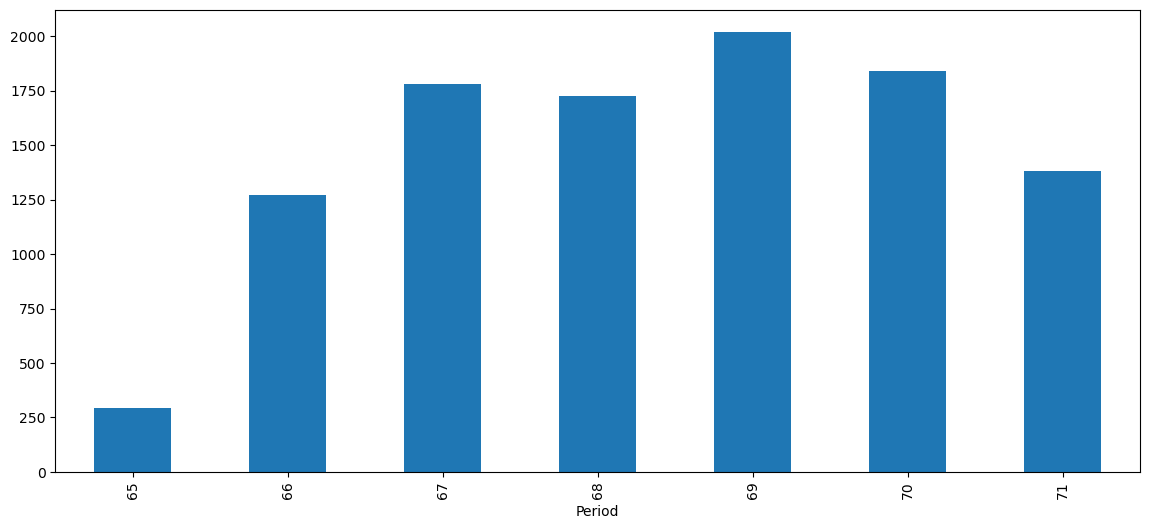

In [14]:
votings_df['Period'].value_counts().sort_index().plot(kind='bar', figsize=(14, 6))